Artificial Neural Networks (ANN) using the Dry Bean Dataset

Why are we learning this?

Imagine you are working for a company that purchases millions of beans from farmers across different regions.

Each bean belongs to a different variety.

Some varieties are premium quality.

Some are used for canned food.

Some are exported.

Some are used as seed beans.

If workers classify every bean manually,

* it is slow,
* expensive,
* inconsistent,
* and impossible at industrial scale.



So the obvious question becomes:

> Can a computer learn to recognize the bean variety just by looking at its physical measurements?

This is exactly the problem we are going to solve.

But another important question immediately follows:

> We already know Machine Learning. Why don't we simply use Decision Trees, Random Forest, or XGBoost?

That question will eventually lead us to Artificial Neural Networks.

Throughout this notebook, we will not treat ANN as a "black box."

Instead, we will build our understanding from a single neuron all the way to a complete deep learning model.



Business Problem

Suppose an agricultural technology company receives thousands of beans every hour.

Each bean is scanned using a vision system, which extracts numerical measurements such as:

* Area
* Perimeter
* Major Axis Length
* Minor Axis Length
* Eccentricity
* Convex Area
* Aspect Ratio
* Roundness
* Compactness
* Shape Factor
* and several other geometric features.

The company's objective is:

> Automatically classify each bean into its correct variety with high accuracy.

A successful classifier helps the business:

* Improve product quality
* Reduce manual labor
* Increase processing speed
* Minimize human errors
* Enable real-time sorting in production lines

This is a classic multiclass classification problem.


Dataset Overview

We will use the Dry Bean Dataset, a well-known benchmark dataset for multiclass classification.

The dataset contains:

* Multiple bean varieties (our target classes)
* Numerical shape-based features extracted from bean images
* One target column representing the bean variety

Unlike image classification, we are not feeding raw images into the neural network.

Instead,

computer vision has already extracted meaningful numerical measurements.

Therefore, our ANN will learn patterns directly from these numerical features.


# Classification Objective

Our goal is straightforward:

Given the measurements of a bean,

predict its correct bean variety.

Mathematically,

[
f(\text{Bean Features}) \rightarrow \text{Bean Class}
]

where

Bean Features =

[
(x_1,x_2,x_3,\ldots,x_n)
]

Output =

One bean class.

For example,

| Bean Features                     | Predicted Variety |
| --------------------------------- | ----------------- |
| Area, Perimeter, Compactness, ... | Seker             |
| Area, Perimeter, Compactness, ... | Bombay            |
| Area, Perimeter, Compactness, ... | Cali              |

Notice something important.

The output is not continuous.

We are not predicting a number.

We are predicting one category among several possible classes.

This distinction will later determine:

* the output layer,
* the activation function,
* and the loss function used by our neural network.


Why Artificial Neural Networks?

At this stage, it is tempting to think:

> "We already know Machine Learning. Why do we need another model?"

That is the wrong question.

The better question is:

> How does a machine actually learn complex relationships between input features?

Traditional machine learning algorithms often rely on manually engineered decision boundaries or specific assumptions about the relationship between features and the target.

Artificial Neural Networks approach the problem differently.

Instead of asking the programmer to define the relationships,

they learn hierarchical feature representations directly from the data.

This ability becomes especially valuable when:

* relationships between features are highly nonlinear,
* many features interact with one another,
* patterns cannot be captured using simple decision boundaries,
* and we want a model that can learn increasingly complex representations.

In this notebook, we will see exactly how this learning happens, starting with a single artificial neuron.

 What We Will Build

By the end of this notebook, you will be able to:

* Understand the mathematics behind one artificial neuron.
* Explain the role of weights and bias.
* Understand activation functions and why they are essential.
* Manually perform forward propagation.
* Understand how TensorFlow automates these computations.
* Build an Artificial Neural Network from scratch using Keras.
* Train, evaluate, tune, and regularize the model.
* Interpret predictions instead of treating the model as a black box.

The emphasis throughout is on understanding every design decision, not memorizing code.


 Transition

We now understand **what problem we are solving** and **why an Artificial Neural Network is a suitable candidate**.

Before a neural network can learn anything, however, the data must be prepared in a form it can understand.


Section 2 — Data Preparation


 Why are we learning this?

Artificial Neural Networks do not understand concepts like:

* Area
* Perimeter
* Compactness
* Bean Variety

They only understand numbers arranged in matrices (tensors).

Before we teach a neural network, we must answer an important question:

> How should we present our dataset so that learning becomes efficient and stable?

Unlike many traditional Machine Learning algorithms, neural networks are particularly sensitive to the scale and representation of the input data.

Poor preprocessing can make training:

* extremely slow,
* unstable,
* or completely fail to converge.

Therefore, data preparation is not just a preprocessing step—it is the foundation of successful deep learning.


Learning Objectives

By the end of this section, you will understand:

* Why neural networks require numerical inputs
* Why target labels must be encoded
* Why feature scaling is almost mandatory for ANN
* Why train-test split is performed before scaling
* What information flows into the neural network

Step 1: Loading the Dataset


Unlike the previous Machine Learning notebooks, we will not spend time performing extensive Exploratory Data Analysis.

Why?

Because our focus has shifted.

Previously, we were trying to understand the dataset.

Now, we are trying to understand how a neural network learns from the dataset.

We only need enough inspection to verify:

* dataset loaded correctly
* feature columns
* target column
* missing values
* class distribution

Everything else has already been covered in Machine Learning.

In [263]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [264]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

In [265]:
df.head().style.background_gradient(cmap='viridis')

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291000,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018000,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110000,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884000,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134000,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [266]:
df.head(1)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER


In [267]:
df.tail().style.background_gradient(cmap='coolwarm')

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
13606,42097,759.696000,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499000,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321000,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779000,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON
13610,42159,772.237000,295.142741,182.204716,1.619841,0.786693,42600,231.686223,0.788962,0.989648,0.888380,0.784997,0.007001,0.001640,0.616221,0.998180,DERMASON


Notice something important.

The neural network will never see the word "SEKER".

It only understands numbers.

That means the target column must eventually become numerical.

We'll do that shortly.


Quick Dataset Inspection

Why are we checking this?

Before training any deep learning model, we must verify that:

* the dataset loaded correctly,
* there are no unexpected missing values,
* and we know the dimensions of the learning problem.


In [268]:
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (13611, 17)


In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [270]:
# Missing values

df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


* Thousands of bean samples
* Multiple numerical feature columns
* One target column named `Class`
* No missing values

Interpretation

This is excellent news.

We do not need:

* imputation,
* missing-value handling,
* or data cleaning.

Our focus can remain entirely on learning neural networks.


Separating Features and Target

Why are we doing this?

A neural network learns a function:

[
f(X) = y
]

where:

X = input features
y = target labels

The model should learn:

> Given these measurements,

predict this bean variety.

Therefore, we separate them.

In [271]:
X = df.drop("Class", axis=1)

In [272]:
y = df["Class"]

In [273]:
print("Feature Matrix Shape :", X.shape)

print("Target Shape         :", y.shape)

Feature Matrix Shape : (13611, 16)
Target Shape         : (13611,)


 Interpretation

At this point:

Each bean is represented by a vector of 16 numerical measurements.

For example:

[
x =
\begin{bmatrix}
Area \
Perimeter \
MajorAxisLength \
\vdots \
ShapeFactor4
\end{bmatrix}
]

Later, these 16 values will become the 16 input neurons of our neural network.

This is the first direct connection between the dataset and the ANN architecture.


Encoding the Target Labels

Why is this necessary?

Our target currently contains text labels such as:

```
SEKER
BARBUNYA
CALI
BOMBAY
DERMASON
...
```

A neural network cannot calculate with text.

It performs operations such as:

* multiplication,
* addition,
* gradient computation,
* optimization.

These require numbers, not strings.

Therefore, we convert each class into an integer.


Intuition

Think of this as assigning an ID card to every bean variety.

| Bean Variety | Encoded Label |
| ------------ | ------------: |
| BARBUNYA     |             0 |
| BOMBAY       |             1 |
| CALI         |             2 |
| DERMASON     |             3 |
| HOROZ        |             4 |
| SEKER        |             5 |
| SIRA         |             6 |

> Important: These numbers are identifiers, not rankings. Class `6` is not "greater" than class `1`; it is simply a different label.


In [274]:
# Create Label Encoder

label_encoder = LabelEncoder()

In [275]:
# Encode target labels

y_encoded = label_encoder.fit_transform(y)

In [276]:
# Display mapping

mapping = dict(

    zip(

        label_encoder.classes_,
        
        label_encoder.transform(label_encoder.classes_)
    )
)

mapping

{'BARBUNYA': np.int64(0),
 'BOMBAY': np.int64(1),
 'CALI': np.int64(2),
 'DERMASON': np.int64(3),
 'HOROZ': np.int64(4),
 'SEKER': np.int64(5),
 'SIRA': np.int64(6)}

 Interpretation

From now on, our neural network will predict integers internally.

Later, we can convert those predictions back to readable bean names using:

```python
label_encoder.inverse_transform(predictions)
```

Train-Test Split

Why do we split before training?

Imagine giving students the exam questions before teaching them.

Scoring 100% would not prove they learned anything.

Similarly, if we evaluate our model on the same data it trained on, the reported accuracy will be misleading.

To measure how well the model generalizes, we reserve a portion of the data that remains unseen during training.


In [277]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,
    
    stratify=y_encoded
)

Why these parameters?

| Parameter            | Why?                                                                                                                            |
| -------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| `test_size=0.20`     | Reserve 20% of the data for unbiased evaluation.                                                                                |
| `random_state=42`    | Ensures reproducible splits, which is important for experiments and debugging.                                                  |
| `stratify=y_encoded` | Preserves the class distribution in both training and test sets, preventing class imbalance from being introduced by the split. |

In [278]:
print("Training Samples :", X_train.shape[0])

print("Testing Samples  :", X_test.shape[0])

Training Samples : 10888
Testing Samples  : 2723


Feature Scaling

Why are we learning this?

This is one of the most important preprocessing steps for neural networks.

Consider two features from the Dry Bean dataset:

| Feature      | Example Value |
| ------------ | ------------: |
| Area         |        28,395 |
| Eccentricity |          0.76 |

Notice the huge difference in magnitude.

Without scaling:

* the `Area` feature would dominate the weighted sum,
* gradients could become unstable,
* optimization would be slower,
* and training may converge poorly.

Traditional tree-based models (e.g., Random Forest, XGBoost) are largely insensitive to feature scaling. Neural networks are not.

Standardizing features helps every input contribute on a comparable scale, allowing gradient-based optimization to work effectively.


 Why do we fit the scaler only on the training data?

A critical rule in machine learning is to avoid data leakage.

If the scaler were fit on the entire dataset, information from the test set would influence the transformation applied during training.

To simulate real-world deployment, we compute scaling parameters (mean and standard deviation) only from the training data, then apply the same transformation to the test data.

In [279]:
# Create the scaler

scaler = StandardScaler()

In [280]:
# Learn scaling parameters from training data and transform the training features

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test features

X_test_scaled = scaler.transform(X_test)

In [281]:
print("Training Feature Matrix Shape :", X_train_scaled.shape)

print("Testing Feature Matrix Shape  :", X_test_scaled.shape)

Training Feature Matrix Shape : (10888, 16)
Testing Feature Matrix Shape  : (2723, 16)


In [282]:
X_train

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
1453,42142,741.324,260.523582,206.118244,1.263952,0.611597,42438,231.639506,0.791488,0.993025,0.963627,0.889131,0.006182,0.002383,0.790553,0.999222
6470,53866,961.806,387.117925,177.923686,2.175753,0.888120,54788,261.886085,0.605168,0.983171,0.731728,0.676502,0.007187,0.000929,0.457655,0.995744
4639,74312,1025.211,390.615917,243.809027,1.602139,0.781292,75060,307.598727,0.808442,0.990035,0.888469,0.787471,0.005256,0.001247,0.620111,0.993503
4655,74460,1044.175,407.437813,234.851357,1.734875,0.817160,75603,307.904882,0.792128,0.984882,0.858196,0.755710,0.005472,0.001101,0.571098,0.990783
1936,49108,799.901,278.853164,224.441402,1.242432,0.593447,49455,250.052490,0.784448,0.992984,0.964472,0.896717,0.005678,0.002265,0.804102,0.999042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2172,57563,986.047,343.635912,213.958916,1.606084,0.782514,58779,270.724007,0.710926,0.979312,0.743975,0.787822,0.005970,0.001419,0.620664,0.996838
5291,85998,1174.800,441.301530,251.922823,1.751733,0.821045,88241,330.901880,0.745423,0.974581,0.783015,0.749832,0.005132,0.001001,0.562248,0.984908
2477,65806,1042.863,361.126192,234.700328,1.538669,0.760009,67326,289.459499,0.707470,0.977423,0.760363,0.801547,0.005488,0.001397,0.642477,0.988560
6431,53505,921.825,375.316539,183.018671,2.050701,0.873046,54350,261.007053,0.753061,0.984453,0.791238,0.695432,0.007015,0.001012,0.483625,0.991771


observe:

* The shapes remain unchanged.

* Feature values are now centered around 0 with a standard deviation close to 1.

* The neural network will receive standardized numerical inputs.

We have now transformed the dataset into a format suitable for a neural network.

The learning pipeline is:

```
Original Dataset
        │
        ▼
Feature / Target Separation
        │
        ▼
Label Encoding
        │
        ▼
Train-Test Split
        │
        ▼
Feature Scaling
        │
        ▼
Ready for Neural Network
```

At this stage, we still have not built a neural network. That is intentional. Preparing the data correctly is a prerequisite for successful training.

Key Takeaways

* Neural networks require numerical inputs and numerical target labels.

* Label encoding converts bean varieties into integer identifiers.

* Train-test splitting provides an unbiased estimate of model performance.

* Feature scaling is especially important for gradient-based learning in ANNs.

* Scaling must be learned from the training data only to avoid data leakage.

* After preprocessing, each bean is represented as a standardized vector of 16 features, ready to enter the network.

> If Machine Learning algorithms can already classify the Dry Bean dataset, why do we need Artificial Neural Networks at all?

In the next section, we will compare the learning capabilities of traditional Machine Learning models and Artificial Neural Networks, understand the 

limitations of conventional approaches, and build the intuition for why deep learning became one of the most influential paradigms in modern AI.

Section 3 — Why Machine Learning Isn't Enough

 Why are we learning this?

Before building an Artificial Neural Network, we should answer a fundamental question.

> If Random Forest, XGBoost, SVM, and Logistic Regression already perform well on many datasets, why were Artificial Neural Networks invented?

As engineers, we should never choose a model simply because it is popular.

Instead, we should understand:

* What problem does it solve?
* What limitations does it overcome?
* When should we use it?
* When should we avoid it?

By the end of this section, you should be able to justify why an ANN is an appropriate choice for a given problem—not just because "deep learning is modern."

Learning Objectives

After completing this section, you will understand:

* The strengths and limitations of traditional Machine Learning.
* The difference between linear and nonlinear relationships.
* Why neural networks learn feature interactions automatically.
* Why ANN is suitable for the Dry Bean dataset.


 Theory

How Does a Machine Learning Model Learn?

Every supervised Machine Learning algorithm tries to learn a mapping:

[
f(X) \rightarrow y
]

where:

X = Input Features
y = Target Class

In our dataset:

[
f(\text{Area},\ \text{Perimeter},\ \text{Compactness},\ ... ) \rightarrow \text{Bean Variety}
]

The important question is:

>How does the model discover this mapping?

Different algorithms answer this differently.

| Algorithm           | Learning Strategy                                                                |
| ------------------- | -------------------------------------------------------------------------------- |
| Logistic Regression | Learns a linear decision boundary                                                |
| Decision Tree       | Splits the feature space into regions                                            |
| Random Forest       | Combines many decision trees                                                     |
| SVM                 | Finds the maximum-margin separating boundary                                     |
| XGBoost             | Sequentially improves weak learners                                              |
| ANN                 | Learns multiple levels of feature representations through interconnected neurons |

Each approach has strengths and trade-offs.

A Real Example from the Dry Bean Dataset

Let's examine two features.

We'll use:

* Area
* Perimeter

These are two measurements available in our dataset.

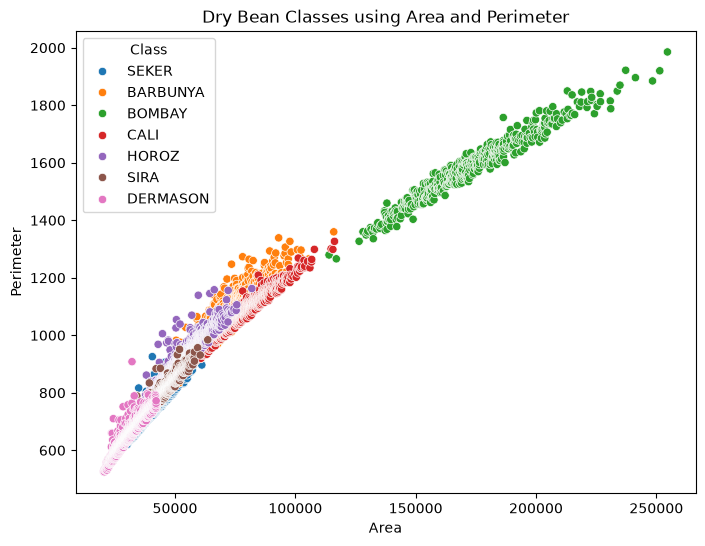

In [283]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df,

    x="Area",

    y="Perimeter",

    hue="Class",

    palette="tab10"
)

plt.title("Dry Bean Classes using Area and Perimeter")

plt.show()

 Interpretation

Suppose we ask Logistic Regression to classify these beans.

It tries to learn a decision boundary like this:

```
-------------------------
```

But our data is distributed in multiple irregular regions.

One straight line is not enough.

Even adding more lines often fails to capture the true structure of the data.

Linear vs Nonlinear Relationships

Why does this matter?

Many classical algorithms either assume or approximate relationships in relatively simple ways.

Real-world data is often much more complex.

For example:

A bean may belong to the CALI class not because its Area is large alone, but because:

* Area is large,
* Compactness is moderate,
* Roundness is high,
* Aspect Ratio is low,
* and several of these features interact.

No single feature determines the answer.

Instead, the combination matters.

Visual Intuition

Linear Boundary

```
Class A     |     Class B

● ● ● ●     |     ▲ ▲ ▲ ▲
● ● ● ●     |     ▲ ▲ ▲ ▲
------------- Decision Boundary
```

A straight line works well.


Nonlinear Boundary

```
▲ ▲ ▲ ▲ ▲

    ● ● ●

▲ ▲ ▲ ▲ ▲
```

Can one straight line isolate the center cluster?

No.

We need a more flexible boundary.

This is where neural networks excel.

Why Feature Interactions Matter

Imagine two beans.

Bean A

| Feature     | Value |
| ----------- | ----- |
| Area        | High  |
| Roundness   | High  |
| Compactness | High  |

---

Bean B

| Feature     | Value |
| ----------- | ----- |
| Area        | High  |
| Roundness   | Low   |
| Compactness | Low   |

Both beans have the same Area.

If Area alone were sufficient, they would belong to the same class.

But they may belong to completely different bean varieties because the relationship between multiple features** determines the class.

Neural networks are designed to learn these interactions automatically.

Why Not Manually Create Every Feature?

In traditional Machine Learning, feature engineering is often crucial.

For example, you might manually create:

```text
Area × Compactness

Area / Perimeter

Roundness²

AspectRatio × Solidity
```

As the number of features grows, the number of possible interactions grows explosively.

With 16 input features, there are:

* 120 unique pairwise interactions,
* hundreds of three-way interactions,
* and thousands of higher-order combinations.

Manually designing all of them is impractical.

Neural networks reduce this burden by learning useful internal representations during training.


 What Does an ANN Actually Learn?

This is a common misconception.

Many beginners believe:

> "A neural network memorizes the data."

It does not.

Instead, each layer transforms the input into a new representation.


Conceptually:

```
Raw Features
      │
      ▼
Basic Feature Combinations
      │
      ▼
More Informative Patterns
      │
      ▼
Higher-Level Representations
      │
      ▼
Prediction
```

Each hidden layer builds upon the representations learned by the previous layer.

This hierarchical learning is one of the defining characteristics of deep learning.

Why Is the Dry Bean Dataset Suitable for an ANN?

Our dataset has several characteristics that make it appropriate for demonstrating neural networks.

 Multiple Numerical Features

Each bean is described by 16 geometric measurements.

The model must learn how these measurements interact.


 Multiple Classes

There are seven bean varieties.

This makes it a multiclass classification problem, allowing us to explore output layers and Softmax activation later in the notebook.

Potentially Complex Relationships

Features such as:

* Area
* Perimeter
* Compactness
* Solidity
* Roundness
* Shape Factors

are not independent.

Their interactions help distinguish bean varieties.

Neural networks are well suited to modeling these relationships.

Should We Always Use ANN?

No.

Choosing a model depends on the problem.

| Situation                                            | Recommended Approach                                             |
| ---------------------------------------------------- | ---------------------------------------------------------------- |
| Small tabular dataset with simple relationships      | Logistic Regression, Decision Tree                               |
| Highly interpretable business model                  | Decision Tree, Linear Models                                     |
| Large structured tabular data                        | Random Forest, XGBoost, CatBoost are often very strong baselines |
| Images                                               | Convolutional Neural Networks (CNNs)                             |
| Text                                                 | Transformers                                                     |
| Audio                                                | Deep Neural Networks / Transformers                              |
| Complex nonlinear relationships with sufficient data | Artificial Neural Networks                                       |

> Professional Practice: For structured tabular data, experienced practitioners often compare ANN with strong gradient boosting models (such as XGBoost or CatBoost) rather than assuming ANN will always perform best.

 A Thought Experiment

Suppose we give the following standardized feature vector to a model:

```text
Area             = 0.83
Perimeter        = 0.61
Compactness      = -0.47
Roundness        = 1.15
AspectRatio      = -0.32
...
```

How does the model decide:

> "This is a SEKER bean."

Where does that decision come from?

Is it a rule?

A tree?

A formula?

Or something else entirely?

The answer lies in the artificial neuron.

Everything a neural network does—whether it has 10 neurons or 10 billion parameters—starts with a single computational unit.

 Key Takeaways

* Traditional Machine Learning and ANNs both learn mappings from inputs to outputs, but they learn them differently.

* Real-world datasets often contain nonlinear relationships and feature interactions that are difficult to model with simple decision boundaries.

* Neural networks automatically learn increasingly informative internal representations instead of relying heavily on manual feature engineering.

* The Dry Bean dataset is a multiclass tabular problem where feature interactions make it a useful example for understanding ANN concepts.

* Neural networks are powerful tools, but they are not automatically the best choice for every dataset.

The next question is much deeper:

> What is the smallest building block of a neural network, and how does it transform 16 numerical features from a single bean into a meaningful prediction?

In the next section, we will build one artificial neuron from scratch, using the first bean in the Dry Bean dataset. We will manually compute the weighted sum, add the bias, implement the calculations with NumPy, and understand exactly what TensorFlow automates behind the scenes.

Section 4 — Understanding One Artificial Neuron

 Why are we learning this?

We often hear statements like:

* "Neural networks learn patterns."
* "The model predicts the bean class."
* "Deep learning is inspired by the human brain."

But how does one neuron actually process data?

Before we build an entire Artificial Neural Network, we must understand its smallest building block.

Think about our dataset.

Every bean is described by 16 numerical features.

A neural network does not magically understand these numbers.

Instead, the first neuron receives these 16 values and performs a sequence of very simple mathematical operations.

If you understand one neuron, then understanding 100 neurons or 100 hidden layers simply becomes repeating the same idea many times.

That is why this section is the most important foundation of the entire notebook.


Learning Objectives

By the end of this section, you will understand:

* What an artificial neuron is
* What inputs, weights, and bias represent
* How a neuron computes its output
* How to manually calculate a neuron's output
* How NumPy performs the same calculation efficiently
* Why TensorFlow's `Dense` layer is simply automating this computation

Theory

What is an Artificial Neuron?

An artificial neuron is a small mathematical function.

Its job is simple:

> Take several input values, combine them intelligently, and produce a single output.

For our Dry Bean dataset:

Each bean has 16 measurements.

One neuron receives all 16 measurements simultaneously.

Conceptually,

```text
               Artificial Neuron

Area --------------------\
Perimeter --------------- \
MajorAxisLength ----------- \
MinorAxisLength ------------ \
Compactness ----------------- > ( Neuron ) ---> Output
Roundness ------------------ /
...
ShapeFactor4 --------------/
```

Notice that the neuron does not decide the bean class by itself.

It only produces one intermediate value.

Many neurons working together eventually produce the final prediction.

Connecting the Theory to the Dry Bean Dataset

In [284]:
first_bean = X_train_scaled[0]

first_bean

array([-0.3713618 , -0.53113068, -0.69536968,  0.08665715, -1.29379955,
       -1.51596432, -0.38003852, -0.36109817,  0.85742085,  1.25610037,
        1.51686446,  1.44683238, -0.33981809,  1.1180828 ,  1.48524952,
        0.95141545])

The important observation is:

> Each value corresponds to one feature of the first bean after scaling.

 Interpretation

This vector is exactly what enters the input layer of the neural network.

We can visualize it as:

| Input Neuron | Feature         |
| ------------ | --------------- |
| x₁           | Area            |
| x₂           | Perimeter       |
| x₃           | MajorAxisLength |
| x₄           | MinorAxisLength |
| ...          | ...             |
| x₁₆          | ShapeFactor4    |

Notice something subtle.

The input neurons do not perform any calculations.

They simply pass these values to the next layer.

The computation begins inside the first hidden neuron.

Step 1 — Inputs

Why are inputs important?

A neuron cannot invent information.

Everything it knows comes from its inputs.

Mathematically,

[
\mathbf{x}
==========

[x_1,x_2,x_3,\ldots,x_{16}]
]

where

* (x_1) = standardized Area
* (x_2) = standardized Perimeter
* ...
* (x_{16}) = standardized ShapeFactor4

In [285]:
# Display each feature with its value for the first bean

feature_values = pd.Series(first_bean, index=X.columns)

feature_values

Area              -0.371362
Perimeter         -0.531131
MajorAxisLength   -0.695370
MinorAxisLength    0.086657
AspectRation      -1.293800
Eccentricity      -1.515964
ConvexArea        -0.380039
EquivDiameter     -0.361098
Extent             0.857421
Solidity           1.256100
roundness          1.516864
Compactness        1.446832
ShapeFactor1      -0.339818
ShapeFactor2       1.118083
ShapeFactor3       1.485250
ShapeFactor4       0.951415
dtype: float64

Interpretation

At this stage, the neuron has 16 pieces of information.

However, it does not know which features are important.

Should Area matter more?

Should Compactness matter less?

How can a neuron decide?

This is where weights enter.


Step 2 — Weights

Why do we need weights?

Imagine two agricultural experts.

Expert A

Believes:

* Area is very important.
* Compactness is moderately important.
* ShapeFactor4 is less important.

 Expert B

Believes:

* Roundness is the most important feature.
* Area hardly matters.

Both experts see the same bean.

Yet they reach conclusions differently because they assign different importance to the features.

A neural network behaves similarly.

It learns how important each feature should be.

Those importance values are called **weights**.

 Mathematics


If our neuron has 16 inputs,

it also has 16 weights.

[
\mathbf{w}
==========

[w_1,w_2,w_3,\ldots,w_{16}]
]

Initially,

these weights are random.

The neuron has not learned anything yet.

Training will gradually improve them.

Since we have not trained a neural network yet, we will create a random weight vector only for demonstration.

In [286]:
# Reproducible random weights for educational purposes

np.random.seed(42)

weights = np.random.randn(X_train_scaled.shape[1])

weights

array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337,
       -0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004,
       -0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783,
       -0.56228753])

Interpretation

These numbers do not come from the dataset.

They are the neuron's initial beliefs.

During training, backpropagation will continuously adjust them.

Think of weights as the neuron's knowledge.

Initially,

that knowledge is random.

Later,

it becomes meaningful.

Step 3 — Multiplying Inputs by Weights

Why multiply?

Suppose

Area has a weight of

[
2.5
]

while

Roundness has a weight of

[
0.1
]

The Area feature will influence the neuron 25 times more than Roundness.

Multiplication allows the neuron to control the contribution of each feature.

Mathematics


Each input is multiplied by its corresponding weight.

[
x_i \times w_i
]

For all features,

[
x_1w_1,
x_2w_2,
x_3w_3,
...
x_{16}w_{16}
]

In [287]:
weighted_inputs = first_bean * weights

weighted_inputs

array([-0.18446066,  0.07343641, -0.45038297,  0.13198142,  0.30294753,
        0.35494327, -0.6001617 , -0.27711928, -0.40253713,  0.68150987,
       -0.70294183, -0.67383289, -0.08222316, -2.13920572, -2.56193339,
       -0.53496904])

Interpretation

The neuron has now evaluated each feature according to its current belief.

Some contributions become:

* positive,
* negative,
* close to zero.

But we still do not have one final value.

The neuron must combine all these contributions.

Step 4 — Weighted Sum

Why sum the values?

The neuron needs a single score summarizing all feature contributions.

Therefore, it adds them together.

Mathematics



[
z
=

x_1w_1
+
x_2w_2
+
...
+
x_{16}w_{16}
]

Using vector notation,

[
z=\mathbf{x}\cdot\mathbf{w}
]

This is simply the dot product between the input vector and the weight vector.

In [288]:
weighted_sum = np.dot(first_bean, weights)

print("Weighted Sum:", weighted_sum)

Weighted Sum: -7.064949261916013


Interpretation

We have compressed 16 input features into one numerical score.

But there is still one missing ingredient.

Step 5 — Bias

Why isn't the weighted sum enough?

Consider the equation of a straight line:

[
y = mx + c
]

Without the constant term (c), the line is forced to pass through the origin.

The constant term gives the model flexibility to shift the decision boundary.

The bias plays the same role in a neuron.

It allows the neuron to adjust its output independently of the inputs.

Mathematics


The neuron's computation becomes:

[
z = \mathbf{x}\cdot\mathbf{w}+b
]

where:

* (\mathbf{x}) = input vector
* (\mathbf{w}) = weights
* (b) = bias

In [289]:
# Random bias for demonstration

bias = 0.35

neuron_output = weighted_sum + bias

print("Neuron Output Before Activation:", neuron_output)

Neuron Output Before Activation: -6.714949261916013


 Interpretation

At this point, our neuron has completed everything it can do without an activation function.

The complete computation is:

[
z
=

\mathbf{x}\cdot\mathbf{w}+b
]

This quantity is often called:

* weighted sum,
* linear combination,
* pre-activation value,
* or simply **logit** (depending on context).

Putting Everything Together

The complete workflow of one neuron is:

```text
First Bean (16 Features)
          │
          ▼
Multiply Each Feature by Its Weight
          │
          ▼
Add All Weighted Values
          │
          ▼
Add Bias
          │
          ▼
Weighted Sum (z)
```

This entire sequence is exactly what every neuron performs.

A Common Misconception

Many beginners believe:

> The neuron predicts the class.

Not yet.

Our neuron has produced only a raw numerical score.

For example:

```text
2.224
```

Is this:

* a probability?
* a class label?
* a confidence score?

None of them.

It is simply a linear combination of inputs.

We still need a mechanism to determine whether this value should be:

* kept,
* compressed,
* ignored,
* or transformed into probabilities.

That mechanism is the activation function.


Key Takeaways

* A neuron receives all 16 standardized features of a bean as input.

* Each input has a corresponding weight that represents its learned importance.

* Inputs are multiplied by their weights and summed using a dot product.

* A bias term adds flexibility, allowing the neuron to shift its response.

* The result (z = \mathbf{x}\cdot\mathbf{w}+b) is a raw score, not yet a prediction.

* This entire computation is the mathematical foundation that TensorFlow's `Dense` layer will later automate.

Transition

Our neuron has successfully computed a weighted sum.

But there is a serious problem.

What if the weighted sum is -15, 0.8, or 27.4?

How can we convert these raw values into meaningful outputs that a neural network can learn from?

In the next section, we will introduce activation functions —the nonlinear component that gives neural networks their expressive power. We will study Sigmoid, Tanh, ReLU, Leaky ReLU, and Softmax**, visualize each one, understand their intuition and mathematics, and relate their roles directly to the Dry Bean classification problem.


Section 5 — Activation Functions

 Why are we learning this?

In the previous section, our neuron successfully calculated a weighted sum:

[
z = \mathbf{x}\cdot\mathbf{w} + b
]

Suppose the neuron produced:

```text
Bean 1 → 18.7
Bean 2 → -6.4
Bean 3 → 0.93
Bean 4 → 27.2
```


Now ask yourself:

> Can we directly use these numbers to classify bean varieties?

The answer is No.

These values are simply raw scores.

They are not:

* probabilities,
* class labels,
* or confidence scores.

Even more importantly, imagine a neural network without activation functions.

Would adding more hidden layers make it more powerful?

Surprisingly,

> No.

Without activation functions, a network with 100 hidden layers behaves mathematically like one single linear transformation.

That means the network cannot learn complex nonlinear relationships.

Activation functions are what make Deep Learning "Deep."

Without them,

there would be no deep learning.


Learning Objectives

By the end of this section, you will understand:

* Why weighted sums are insufficient
* Why activation functions introduce nonlinearity
* The intuition and mathematics behind:

  * Sigmoid
  * Tanh
  * ReLU
  * Leaky ReLU
  * Softmax
  
* When each activation function should be used
* Why Softmax is ideal for the Dry Bean dataset

 Why Can't We Stop at the Weighted Sum?

Recall our neuron:

```text
16 Features
      │
      ▼
Weights
      │
      ▼
Weighted Sum
      │
      ▼
      7.83
```

What does 7.83 actually mean?

Nothing by itself.

The neuron needs a mechanism to transform this raw score into something meaningful.

That transformation is called an Activation Function.

Conceptually,

```text
Input Features
       │
       ▼
Weighted Sum (z)
       │
       ▼
Activation Function
       │
       ▼
Neuron Output
```

Theory

What is an Activation Function?

An activation function is simply a mathematical function:

[
a=f(z)
]

where

* (z) = weighted sum

* (f) = activation function

* (a) = neuron's final output


The activation function decides

> How much of the neuron's information should be passed to the next layer?

 Why Nonlinearity Matters

Imagine trying to separate bean varieties using only straight lines.

Earlier we saw that the Dry Bean classes overlap in complex ways.

Suppose we stack three neurons without activation functions.

Mathematically,

Layer 1:

[
z_1=W_1x+b_1
]

Layer 2:

[
z_2=W_2z_1+b_2
]

Layer 3:

[
z_3=W_3z_2+b_3
]

Substituting them together still produces

[
z_3=Wx+b
]

which is just another linear equation.

This means:

> 100 linear layers are still equivalent to one linear layer.

Adding layers alone does not increase learning power.

Activation functions break this limitation by introducing nonlinearity, allowing the network to model complex patterns.

The Activation Functions We'll Study

| Activation | Typical Use                           |
| ---------- | ------------------------------------- |
| Sigmoid    | Binary classification output          |
| Tanh       | Older hidden layers, centered outputs |
| ReLU       | Default hidden-layer activation       |
| Leaky ReLU | Addresses ReLU's dead neuron issue    |
| Softmax    | Multiclass classification output      |

 1. Sigmoid Activation

 Why was Sigmoid invented?

Suppose a neuron outputs

```text
27.4
```

or

```text
-18.2
```

These values are difficult to interpret.

Sigmoid converts any real number into a value between 0 and 1.

This makes the output interpretable as a probability-like score.

 Mathematics

[
\sigma(z)=\frac{1}{1+e^{-z}}
]


Output Range

[
0 \leq \sigma(z)\leq1
]

Visual Intuition

```text
1.0 |               _______
    |            __/
0.5 |----------/
    |       __/
0.0 |______/
      -∞      +∞
```

Large negative values become close to 0.

Large positive values become close to 1.

In [290]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [291]:
# Use the weighted sum calculated in the previous section

sigmoid_output = sigmoid(neuron_output)

print(sigmoid_output)

0.0012111788047795013



This does **not** mean

> "90.2% probability that the bean is SEKER."

At this stage, it is simply the output of one neuron.

Only the final output layer can be interpreted probabilistically.


Graph

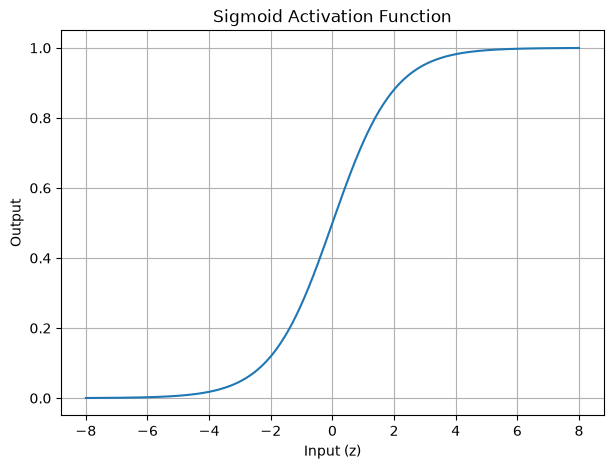

In [292]:

x = np.linspace(-8, 8, 500)

plt.figure(figsize=(7,5))

plt.plot(x, sigmoid(x))

plt.title("Sigmoid Activation Function")

plt.xlabel("Input (z)")

plt.ylabel("Output")

plt.grid(True)

plt.show()

Interpretation

Sigmoid compresses every value into

[
0\rightarrow1
]

Historically it was widely used,

but today it is rarely used in hidden layers because of gradient-related issues that we will study during backpropagation.

It is still useful for binary classification output layers.

2. Tanh Activation

Why introduce another activation?

Sigmoid outputs values between

[
0 \text{ and }1
]

Notice something.

Its outputs are not centered around zero.

This can slow optimization because the activations entering the next layer are always positive.

Tanh addresses this by producing outputs between -1 and 1, making the activations zero-centered.

Mathematics

[
\tanh(z)=
\frac{e^z-e^{-z}}
{e^z+e^{-z}}
]

In [293]:
def tanh(x):
    return np.tanh(x)

In [294]:
tanh_output = tanh(neuron_output)

print(tanh_output)

-0.999997058976223


Graph

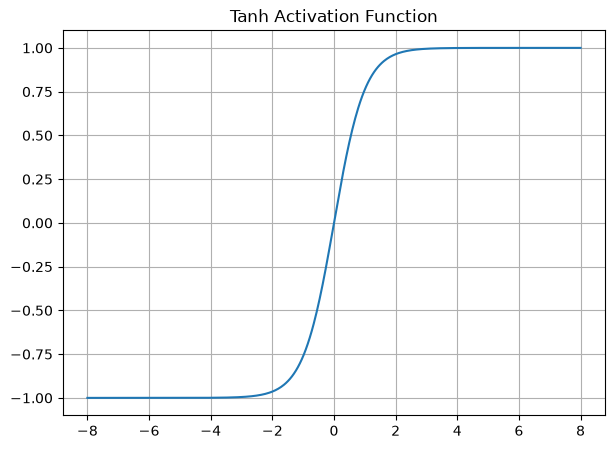

In [295]:
plt.figure(figsize=(7,5))

plt.plot(x, tanh(x))

plt.title("Tanh Activation Function")

plt.grid(True)

plt.show()

Interpretation

Compared to Sigmoid,

Tanh:

* is zero-centered,
* often trains faster than Sigmoid in hidden layers,
* but still suffers from saturation for very large positive or negative inputs.

Today, it is less common than ReLU for hidden layers but still appears in some architectures (e.g., certain recurrent neural networks).

3. ReLU (Rectified Linear Unit)

Why was ReLU created?

Researchers observed that Sigmoid and Tanh often slowed training in deep networks because their gradients become very small for extreme input values.

ReLU introduced a much simpler rule.

If the weighted sum is positive,

keep it.

If it is negative,

replace it with zero.

Mathematics

[
ReLU(z)=
\max(0,z)
]

Visual Intuition

```text
 ^
 |
 |
 |          /
 |         /
 |        /
 |_______/
 |
 +-------------------->
```

In [296]:
def relu(x):
    return np.maximum(0, x)

In [297]:
relu_output = relu(neuron_output)

print(relu_output)

0.0


Graph

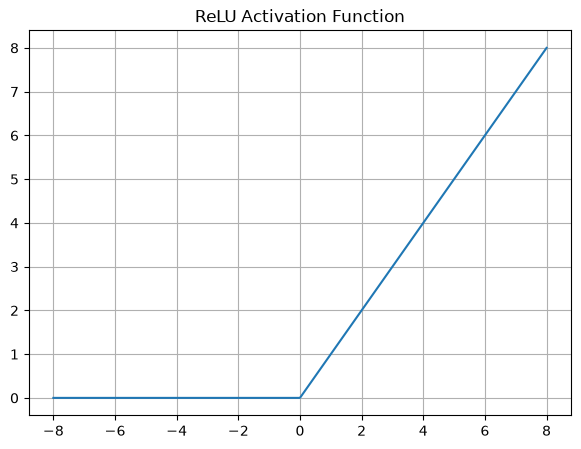

In [298]:
plt.figure(figsize=(7,5))

plt.plot(x, relu(x))

plt.title("ReLU Activation Function")

plt.grid(True)

plt.show()

Interpretation

Suppose our first bean produced:

```text
2.4
```

ReLU returns

```text
2.4
```

Suppose another bean produced

```text
-3.1
```

ReLU returns

```text
0
```

ReLU is computationally efficient and helps deep networks train effectively.

It is the default activation for hidden layers in many modern feedforward networks.


4. Leaky ReLU

Why improve ReLU?

ReLU has one limitation.

If a neuron consistently receives negative inputs, its output remains zero.

Such a neuron may stop learning because its gradient can become zero for all negative inputs.

This situation is often called the "dying ReLU" problem.

Leaky ReLU addresses this by allowing a small negative slope.

Instead of outputting exactly zero for negative values, it outputs a small fraction of the input.


 Mathematics

[
LeakyReLU(z)=
\begin{cases}
z,&z>0\
0.01z,&z<0
\end{cases}
]

In [299]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

In [300]:
leaky_output = leaky_relu(neuron_output)

print(leaky_output)

-0.06714949261916013


Graph

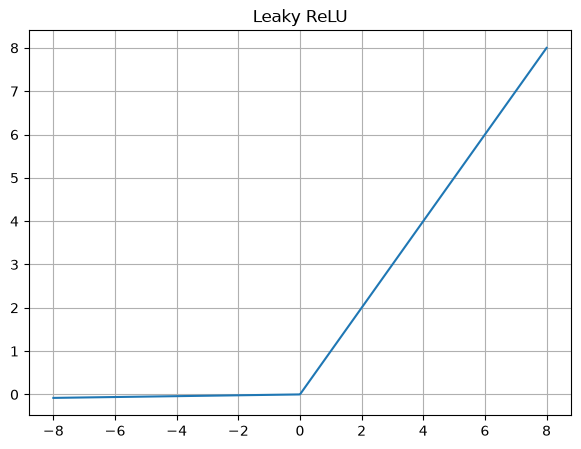

In [301]:
y = leaky_relu(x)

plt.figure(figsize=(7,5))

plt.plot(x, y)

plt.title("Leaky ReLU")

plt.grid(True)

plt.show()

Interpretation

Leaky ReLU behaves almost like ReLU for positive inputs, but preserves a small gradient for negative values, helping neurons continue to learn even when their inputs are mostly negative.

 5. Softmax Activation


Why do we need Softmax?

Recall our problem.

We are not predicting:

* Yes/No
* Fraud/Not Fraud
* Disease/No Disease

Instead, we have seven bean varieties.

Suppose the output layer produces these raw scores (logits) for the first bean:

| Bean Variety | Raw Score |
| ------------ | --------: |
| BARBUNYA     |       1.4 |
| BOMBAY       |       2.1 |
| CALI         |       4.7 |
| DERMASON     |       1.2 |
| HOROZ        |       0.9 |
| SEKER        |       3.8 |
| SIRA         |       2.5 |

These values are not probabilities.

Softmax transforms them into probabilities that sum to 1.

Mathematics

[
P_i=
\frac{e^{z_i}}
{\sum_j e^{z_j}}
]

where (z_i) is the logit for class (i).

In [302]:
logits = np.array([1.4, 2.1, 4.7, 1.2, 0.9, 3.8, 2.5])

softmax = np.exp(logits) / np.sum(np.exp(logits))

softmax

array([0.02193993, 0.04418159, 0.59484942, 0.0179629 , 0.01330724,
       0.24184773, 0.06591119])

These probabilities sum to approximately **1.0**.

Interpretation

The model would predict CALI because it has the highest probability.

Notice that Softmax does not simply pick the largest score—it converts all scores into a valid probability distribution.

This makes it the standard choice for multiclass classification, including the Dry Bean dataset.

Comparing Activation Functions

| Activation | Output Range      | Hidden Layer  | Output Layer              | Advantages                          | Limitations                                |
| ---------- | ----------------- | ------------- | ------------------------- | ----------------------------------- | ------------------------------------------ |
| Sigmoid    | (0, 1)            | Rarely        | Binary Classification     | Probability-like output             | Saturation, non-zero-centered              |
| Tanh       | (-1, 1)           | Sometimes     | Rarely                    | Zero-centered                       | Saturation                                 |
| ReLU       | [0, ∞)            | Yes (default) | No                        | Fast, effective, sparse activations | Dying ReLU                                 |
| Leaky ReLU | (-∞, ∞)           | Yes           | No                        | Mitigates dying ReLU                | Additional hyperparameter (negative slope) |
| Softmax    | (0, 1), sums to 1 | No            | Multiclass Classification | Produces class probabilities        | Used only for mutually exclusive classes   |

Key Takeaways

* A weighted sum alone cannot model complex nonlinear relationships.

* Activation functions introduce the nonlinearity that gives deep neural networks their expressive power.

* Sigmoid and Tanh were historically important but are less common in hidden layers today.

* ReLU is the default activation for most hidden layers because of its simplicity and effectiveness.

* Leaky ReLU addresses one of ReLU's main limitations.

* Softmax is the appropriate output activation for the Dry Bean dataset because it predicts one of seven mutually exclusive classes as probabilities.

Transition

We now understand how one neuron transforms its inputs into an output.

But one neuron is far too limited to distinguish seven bean varieties based on 16 interacting features.

The next question naturally arises:

> How do hundreds of neurons work together to learn increasingly complex patterns.

In the next section, we will build the intuition behind hidden layers, understand why they exist, how they create hierarchical feature representations, and why stacking neurons makes neural networks far more powerful than a single neuron.


Section 6 — Hidden Layers

Why are we learning this?

In the previous section, we built one artificial neuron.

It received the 16 features of a bean, calculated:

[
z = \mathbf{x}\cdot\mathbf{w} + b
]

applied an activation function, and produced one output.


Now ask yourself:

> Can one neuron distinguish all seven bean varieties?

Let's think about it.

Our Dry Bean dataset contains 7 different classes and 16 numerical features.

A single neuron only learns one mathematical relationship.

Real-world data contains hundreds of relationships happening simultaneously.

One neuron is simply not powerful enough.

This leads to the next question:

> What if many neurons worked together?

That idea gives birth to the Hidden Layer.

Learning Objectives

By the end of this section, you will understand:

* Why one neuron is insufficient
* What a hidden layer actually is
* Why hidden layers are called "hidden"
* How hidden layers learn new representations
* Why stacking hidden layers increases learning capacity
* Why more hidden layers do not** always mean better performance


The Big Picture

Recall our dataset.

Each bean has:

* Area
* Perimeter
* Major Axis Length
* Minor Axis Length
* Compactness
* Roundness
* Solidity
* Shape Factors
* ...

These measurements are just raw numbers.

A neural network does not know what they mean.

Instead,

it gradually transforms them into increasingly useful representations.

Think of this process as translating information into a language that makes classification easier.

What is a Hidden Layer?

A hidden layer is simply a collection of neurons.

Instead of having one neuron,

we may have:

* 8 neurons
* 16 neurons
* 32 neurons
* 64 neurons
* 128 neurons

Each neuron learns something different about the same bean.

Conceptually,

```text
                Hidden Layer

          ○   ○   ○   ○
        ○   ○   ○   ○   ○
          ○   ○   ○   ○
```

Every neuron receives the same input features.

But because every neuron has different weights,

each neuron learns a different pattern.

Why is it Called a Hidden Layer?

Consider the network below.

```text
Input Layer          Hidden Layer          Output Layer

Area  --------\
Perimeter -----\
Compactness -----> ○
Roundness -------> ○ --------> Bean Variety
...
Feature16 -------> ○
```

The input layer is visible.

The output layer is visible.

The middle layer performs computations internally.

We cannot directly observe the meaning of each neuron.

Therefore,

it is called the Hidden Layer.


Connecting to the Dry Bean Dataset

Suppose we have one bean.

It contains 16 standardized features.

Instead of sending them to one neuron,

we send them to four neurons.

```text
                Bean Features

Area ------------------------\
Perimeter --------------------\
Compactness -------------------\
Roundness -----------------------> N1
Aspect Ratio ---------------------> N2
ShapeFactor ----------------------> N3
...
Feature16 ------------------------> N4
```

Notice something important.

Every neuron receives the same bean.

Yet every neuron produces a different output because each has learned different weights.

Why Do Different Neurons Learn Different Things?

Imagine four agricultural experts examining the same bean.

Expert 1

Focuses on

* Area
* Perimeter


Expert 2

Focuses on

* Compactness
* Roundness


Expert 3

Focuses on

* Shape Factors

Expert 4

Focuses on

* Aspect Ratio

All four experts see the same bean.

But they specialize in different characteristics.

Neurons behave in a similar way.

Each neuron develops its own specialization during training.

No programmer explicitly assigns these roles; they emerge from optimization.

Visualizing a Hidden Layer

Suppose we choose 4 neurons in our hidden layer.

The architecture looks like this:

```text
                  Hidden Layer

             ○
Area -------/ \
             ○
Perimeter --\ /
             ○
Compactness-/ \
             ○

Roundness
...
ShapeFactor4
```

Each neuron computes:

[
z=\mathbf{x}\cdot\mathbf{w}+b
]

followed by an activation function.

The outputs from all neurons are then passed to the next layer.


Mathematical Perspective

Suppose

our input vector is

[
x=
[x_1,x_2,\ldots,x_{16}]
]

Instead of one neuron,

we now have four.

Neuron 1

[
a_1=f(W_1x+b_1)
]

Neuron 2

[
a_2=f(W_2x+b_2)
]

Neuron 3

[
a_3=f(W_3x+b_3)
]

Neuron 4

[
a_4=f(W_4x+b_4)
]

Collectively,

the hidden layer produces

[
[a_1,a_2,a_3,a_4]
]

These outputs become the inputs to the next layer.

What is the Hidden Layer Actually Learning?

This is one of the biggest misconceptions in deep learning.

Many beginners imagine a neuron learning a human-readable rule such as:

```text
IF Area > 30000

THEN Bean = CALI
```

That is not what happens.

Instead,

neurons learn mathematical transformations.



For example,

Neuron 1 may become sensitive to:

* larger areas combined with higher compactness.

Neuron 2 may respond strongly to:

* elongated beans with low roundness.

Neuron 3 may activate for:

* combinations of shape factors that frequently occur in one bean variety.

These are learned representations, not explicit rules.

Representation Learning

One of the defining strengths of neural networks is representation learning.

Instead of requiring us to engineer every feature manually, the network learns useful representations automatically.

Think of the hidden layer as creating new features.


Original Features

```text
Area

Perimeter

Roundness

Compactness

...
```

↓

 Hidden Layer Learns

```text
Pattern 1

Pattern 2

Pattern 3

Pattern 4

...
```

These learned patterns are often more informative than the original measurements for the classification task.

Why Multiple Hidden Layers?

Suppose we add another hidden layer.

```text
Input

↓

Hidden Layer 1

↓

Hidden Layer 2

↓

Output
```

What changes?

Hidden Layer 1 learns simple patterns.

Hidden Layer 2 combines those simple patterns into more abstract patterns.

Conceptually,

```text
Raw Features

↓

Basic Relationships

↓

Complex Relationships

↓

Prediction
```

This hierarchy is what gives deep learning its name.

A Real Analogy

Imagine identifying a bean manually.

First, you notice:

* its size,
* its length,
* its width.

Then you combine these observations to infer:

* whether it is elongated,
* whether it is compact,
* whether it is symmetrical.

Finally,

you combine those higher-level observations to determine the bean variety.

Neural networks perform a similar progression—from simple measurements to complex concepts—through stacked hidden layers.

Visualizing the Architecture

We are not using TensorFlow yet.

Instead, we will simply illustrate a possible architecture.


In [303]:
print("""
Input Layer (16 Features)
        │
        ▼
Hidden Layer 1 (8 Neurons)
        │
        ▼
Hidden Layer 2 (4 Neurons)
        │
        ▼
Output Layer (7 Classes)
""")


Input Layer (16 Features)
        │
        ▼
Hidden Layer 1 (8 Neurons)
        │
        ▼
Hidden Layer 2 (4 Neurons)
        │
        ▼
Output Layer (7 Classes)



 Interpretation

This architecture tells us:

* The input layer receives 16 standardized measurements.
* The first hidden layer transforms these measurements into  8 learned representations.
* The second hidden layer builds on those representations to create 4 more abstract features.
* The output layer uses those learned features to predict one of the 7 bean classes.

At this stage, the numbers 8 and 4 are design choices—not fixed rules. In the next section, we will learn how professionals decide how many neurons and hidden layers to use.

Common Misconceptions

Misconception 1

> More hidden layers always produce better models.

Reality: Additional layers increase model capacity, but they can also increase training time and the risk of overfitting. The best architecture depends on the data and is validated experimentally.

 Misconception 2

> Every neuron learns the same thing.

Reality: Each neuron has different weights and therefore learns different feature combinations.


Misconception 3

> Hidden neurons correspond to human-understandable concepts.

Reality: Some learned representations may be interpretable, but many are abstract mathematical features that collectively improve prediction accuracy.

Key Takeaways

* A hidden layer is a collection of neurons that operate in parallel on the same input.

* Each neuron learns a different representation because it has its own weights and bias.

* Hidden layers transform raw features into progressively more informative internal representations.

* Stacking hidden layers enables hierarchical learning, allowing the network to model increasingly complex relationships.

* The number of hidden layers and neurons is a design choice that should be guided by experimentation and validation rather than fixed rules.

A practical question immediately follows:

> Why do many tutorials use 64 neurons? Why not 10, 32, 128, or 512? How many hidden layers should we actually use for the Dry Bean dataset?**

In the next section, we will discuss how experienced deep learning practitioners choose the number of hidden layers and neurons, the trade-offs involved, and the reasoning behind common architectural decisions.


Section 7 — Choosing Hidden Layers and Neurons

Why are we learning this?

One of the first questions beginners ask is:

> Why do most tutorials use 64 neurons?

Then another tutorial uses:

* 32 neurons
* 128 neurons
* 256 neurons

Who's correct?

The surprising answer is:

> All of them could be correct—or all of them could be wrong.

There is no universal formula that says:

```python
Dense(64)
```

is always the right choice.

Professional Deep Learning Engineers do not memorize architectures.

They make informed design decisions based on:

* the problem,
* the dataset,
* computational resources,
* and experimental evidence.

This section teaches you how to think, not what numbers to memorize.

Learning Objectives

By the end of this section, you will understand:

* Why the number of neurons is a hyperparameter
* What happens when there are too few or too many neurons
* Why deeper isn't always better
* Practical guidelines professionals use
* How to design an ANN for the Dry Bean dataset


What is a Hyperparameter?

Before answering "Why 64 neurons?", let's distinguish two important concepts.

| Model Parameters                      | Hyperparameters         |
| ------------------------------------- | ----------------------- |
| Learned automatically during training | Chosen before training  |
| Weights                               | Number of hidden layers |
| Biases                                | Number of neurons       |
| Updated by backpropagation            | Learning rate           |
|                                       | Batch size              |
|                                       | Activation function     |

Notice:

> The network learns weights, but it does not learn how many neurons it should have.

That decision comes from us.


 The Capacity of a Neural Network

Imagine giving two students the same exam.

Student A

Knows only addition.

Student B

Knows:

* algebra
* calculus
* probability
* optimization

Who is more likely to solve difficult problems?

Student B.

Similarly,

a neural network with more neurons has greater learning capacity.

Capacity refers to the model's ability to learn complex patterns.


Too Few Neurons

Suppose we build:

```text
16 Inputs

↓

2 Hidden Neurons

↓

7 Outputs
```

Can only two neurons summarize everything about:

* Area
* Perimeter
* Shape Factors
* Compactness
* Roundness
* Solidity

for seven bean classes?

Probably not.

The network may miss important relationships.

This is called underfitting.

Visual Intuition

```text
Real Pattern

**************
**************
**************

Model Learns

******
******
```

The model is too simple.

It cannot capture the complexity of the data.


 Too Many Neurons

Now imagine:

```text
16 Inputs

↓

5000 Hidden Neurons

↓

7 Outputs
```

Can it learn?

Yes.

But another problem appears.

The model may begin memorizing the training data instead of learning general patterns.

This is called overfitting.


Visual Intuition

```text
Training Data

● ● ● ● ● ●

Model

Connects every point individually

instead of learning the trend.
```

The model performs extremely well on training data but poorly on unseen beans.


The Bias–Variance Trade-off

Choosing the number of neurons is fundamentally about balancing two competing goals.

| Too Small | Balanced                   | Too Large     |
| --------- | -------------------------- | ------------- |
| Underfits | Generalizes Well           | Overfits      |
| High Bias | Good Bias–Variance Balance | High Variance |

Our objective is not the largest model.

Our objective is the model that performs best on unseen data.


Why Do Tutorials Often Use 64 Neurons?

The answer is surprisingly simple.

There is nothing mathematically special about 64.

Historically, powers of two such as:

```text
8

16

32

64

128

256
```

became common because computer hardware stores and processes data efficiently in binary units.

Modern GPUs also handle these sizes efficiently, although performance differences are often minor for small tabular models.

So,

```python
Dense(64)
```

is not a rule.

It is merely a practical and convenient starting point.

How Professionals Choose the Number of Neurons

Experienced practitioners rarely guess once and stop.

Instead, they follow an iterative process.

```text
Choose Initial Architecture

↓

Train Model

↓

Evaluate Validation Performance

↓

Adjust Architecture

↓

Repeat
```

Model architecture is refined through experimentation, not intuition alone.


Designing for the Dry Bean Dataset

Let's examine our problem.

Number of Features

16

This is relatively small.

 Number of Samples

Around thirteen thousand beans.

This is a moderate-sized dataset.

Number of Classes

7

Moderately complex.


 Feature Type

Structured numerical data.

Not images.

Not text.

 What does this imply?

Unlike image classification,

we do not need

* dozens of layers,
* millions of neurons,
* or billions of parameters.

A relatively compact ANN is often sufficient for this type of structured tabular data.


A Reasonable Starting Architecture

One reasonable starting point could be:

```text
Input Layer

16 Features

↓

Hidden Layer

64 Neurons

↓

Hidden Layer

32 Neurons

↓

Output Layer

7 Classes
```


Why?

The first hidden layer has enough capacity to learn many combinations of the 16 input features.

The second hidden layer compresses those learned representations into more task-specific features before the final prediction.

This is not the only valid design—it is a practical baseline to evaluate and improve.


Why Gradually Reduce Neurons?

Notice the architecture:

```text
64

↓

32

↓

7
```

Why not

```text
64

↓

64

↓

64
```

or

```text
512

↓

8
```

A common design principle is progressive compression.

Think of summarizing a long research paper.

Initially,

you have many details.

Then,

you identify key ideas.

Finally,

you produce a concise conclusion.

Similarly,

hidden layers gradually compress information while preserving the most useful patterns.

Visual Representation

```text
16 Features

↓

64 Learned Features

↓

32 More Informative Features

↓

7 Class Scores
```

Each stage attempts to retain what is useful while discarding irrelevant information.

How Many Hidden Layers?

Again,

there is no universal answer.

However, practical guidelines help.

| Dataset Type             | Typical Hidden Layers         |
| ------------------------ | ----------------------------- |
| Simple tabular dataset   | 1–2                           |
| Moderate tabular dataset | 2–4                           |
| Image recognition        | Often dozens of layers (CNNs) |
| Language models          | Many transformer blocks       |

For the Dry Bean dataset,

1–2 hidden layers are usually a sensible starting point because:

* the feature space is modest,
* the relationships are nonlinear but not extremely high-dimensional,
* and the dataset size does not justify a very deep network.


Should We Always Build Bigger Networks?

No.

Consider these trade-offs.

| Larger Model                 | Smaller Model          |
| ---------------------------- | ---------------------- |
| Learns more complex patterns | Faster training        |
| Higher memory usage          | Easier deployment      |
| Greater overfitting risk     | May underfit           |
| Longer experimentation       | Simpler interpretation |

Professional engineers balance accuracy with computational efficiency and maintainability.


 How Will We Know If Our Architecture Is Good?

We do not decide based on intuition alone.

Instead, we compare architectures experimentally.

For example:

| Model   | Hidden Layers | Neurons       | Validation Accuracy |
| ------- | ------------- | ------------- | ------------------- |
| Model A | 1             | 16            | 91.8%               |
| Model B | 1             | 64            | 94.7%               |
| Model C | 2             | 64 → 32       | 96.2%               |
| Model D | 3             | 128 → 64 → 32 | 95.8%               |

This illustrates an important principle:

The largest network is not necessarily the best.

Validation performance guides architectural decisions.

Later in the notebook, we will perform this comparison using real experiments.

Code — Defining Candidate Architectures

We are still not using TensorFlow.

Instead, we simply define candidate architectures conceptually.


In [304]:
candidate_architectures = {
    "Model_A": [16],
    "Model_B": [32],
    "Model_C": [64, 32],
    "Model_D": [128, 64, 32]
}

candidate_architectures

{'Model_A': [16],
 'Model_B': [32],
 'Model_C': [64, 32],
 'Model_D': [128, 64, 32]}

Common Myths

 Myth 1

> More neurons always increase accuracy.

Reality: Beyond a certain point, additional neurons often provide diminishing returns and may increase overfitting.

 Myth 2

> There is a formula for choosing hidden layers.

Reality: There are heuristics, but no universally correct formula. Architecture selection is an engineering decision supported by validation experiments.

 Myth 3

> Deep learning always requires deep networks.

Reality: Many structured tabular datasets achieve excellent performance with one or two hidden layers.

 Myth 4

> If the model trains well, the architecture must be good.

Reality: A model that performs exceptionally on the training set but poorly on unseen data is not a successful model.


Key Takeaways

* The number of hidden layers and neurons are hyperparameters, chosen before training.

* Too few neurons can lead to underfitting; too many can increase overfitting.

* Common sizes like 32 and 64 are practical starting points, not mathematical rules.

* Architecture selection should be driven by validation performance, not guesswork.

* For the Dry Bean dataset, a compact architecture such as 64 → 32 is a reasonable baseline to evaluate.

Transition

We now know what a hidden layer is and how to choose its size.

But an important question remains:

> When a bean passes through multiple hidden layers, how are all the neurons' calculations connected together?

In the next section, we will manually perform forward propagation using the first bean from the Dry Bean dataset. We will calculate each step with NumPy, observe how information flows through the network, and then see how TensorFlow automates exactly the same computations behind a single `Dense` layer.


Section 8 — Forward Propagation

 Why are we learning this?

In the previous sections, we learned:

* What a neuron is
* What weights and bias do
* Why activation functions are necessary
* Why hidden layers exist
* How to choose the number of neurons

Now let's answer the most important question so far:

> How does information actually travel through an entire neural network?

Suppose we give our network the first bean from the Dry Bean dataset.

What happens next?

Does TensorFlow somehow "understand" the bean?

No.

It simply performs thousands of matrix operations very efficiently.

Understanding these operations is called Forward Propagation.

Once you understand forward propagation, TensorFlow's `Dense()` layer will no longer feel like magic—it will simply automate calculations that you already know.


Learning Objectives

By the end of this section, you will understand:

* What Forward Propagation is
* How one sample moves through a neural network
* Matrix multiplication in neural networks
* Why matrix operations are used instead of loops
* How to manually implement forward propagation using NumPy
* How TensorFlow performs the same computations internally


 What is Forward Propagation?

Forward propagation is the process of moving information from:

```text
Input Layer
      │
      ▼
Hidden Layer(s)
      │
      ▼
Output Layer
```

using the learned:

* Weights
* Biases
* Activation Functions

The word forward simply means:

> Information always flows from the input toward the output during prediction.

 Big Picture

Suppose our network architecture is

```text
16 Inputs

↓

Hidden Layer (4 Neurons)

↓

Output Layer (7 Neurons)
```

When one bean enters the network,

the computations happen like this.

```text
Bean Features

↓

Hidden Layer Calculations

↓

Hidden Layer Outputs

↓

Output Layer Calculations

↓

Class Probabilities
```

Every prediction follows this sequence.

 Connecting to Our Dataset

Instead of using an artificial vector,

we again use the first bean from the Dry Bean dataset.


In [305]:
first_bean = X_train_scaled[0]

print("Input Shape:", first_bean.shape)

Input Shape: (16,)


Step 1 — Inputs Enter the Network

Our input vector is

[
x=
[x_1,x_2,\ldots,x_{16}]
]

These values are the standardized measurements of one bean.

For example,

| Feature     | Example Value |
| ----------- | ------------: |
| Area        |          0.82 |
| Perimeter   |         -0.31 |
| Compactness |          1.14 |
| ...         |           ... |

Nothing has been learned yet.

These are simply the inputs.


Step 2 — Hidden Layer Weights

Suppose our hidden layer contains **4 neurons**.

Each neuron receives all 16 input features.

Therefore,

each neuron needs

16 weights + 1 bias.

The weight matrix therefore has shape

[
16\times4
]

Let's understand why.


Matrix Dimensions

| Layer         | Shape  |
| ------------- | ------ |
| Input Vector  | (16,)  |
| Weight Matrix | (16,4) |
| Bias Vector   | (4,)   |
| Hidden Output | (4,)   |

Notice something elegant.

Each column of the weight matrix belongs to one hidden neuron.

In [306]:
np.random.seed(42)

hidden_weights = np.random.randn(16, 4)

hidden_bias = np.random.randn(4)

Why Are We Using a Matrix?

In Section 4,

we multiplied

```text
Input × Weight
```

for one neuron.

Now we have four neurons.

We could calculate

Neuron 1

Neuron 2

Neuron 3

Neuron 4

one by one.

But that would be inefficient.

Instead,

matrix multiplication computes all neurons simultaneously.

This is one of the main reasons deep learning libraries are so fast.

Step 3 — Matrix Multiplication

Mathematically,

[
Z=XW+b
]

where

[
X=(1\times16)
]

[
W=(16\times4)
]

Result

[
Z=(1\times4)
]

Notice how the dimensions match.

```text
(1×16)

×

(16×4)

=

(1×4)
```

The inner dimensions cancel.

This is exactly why matrix multiplication is valid.

In [307]:
hidden_linear = np.dot(first_bean, hidden_weights) + hidden_bias

hidden_linear

array([-2.73204034, -2.51514072, -0.57432706,  5.23711962])

Interpretation

At this point,

our hidden layer has produced

four weighted sums.

However,

these are not the hidden layer outputs yet.

They still need activation functions.


Step 4 — Apply ReLU

Recall

ReLU

[
ReLU(x)=\max(0,x)
]


In [308]:
hidden_output = np.maximum(0, hidden_linear)

hidden_output

array([0.        , 0.        , 0.        , 5.23711962])

is not the final prediction.

It becomes the input for the next layer.

---

Hidden Layer Summary

Let's summarize.

```text
16 Inputs

↓

Weighted Sum

↓

ReLU

↓

4 Outputs
```

Those four outputs become new features.

Notice something fascinating.

The original bean had

16 engineered measurements.

After passing through the hidden layer,

the network has created

4 entirely new learned features.

These learned features are often more useful for classification than the original measurements.

Step 5 — Output Layer

Our dataset contains

7 bean varieties.

Therefore,

our output layer needs

7 neurons.

Each hidden neuron connects to every output neuron.


 Weight Matrix

Input

4 values

Output

7 neurons

Weight matrix

[
4\times7
]

Bias

[
7
]

In [309]:
output_weights = np.random.randn(4,7)

output_bias = np.random.randn(7)

Step 6 — Compute Output Layer


Again,

we perform

[
Z=XW+b
]

In [310]:
logits = np.dot(hidden_output, output_weights) + output_bias

logits

array([ 2.98416322,  0.76946201,  5.07802314, -3.91132316, -3.1313766 ,
       -2.47416262, -8.00731736])

These values are called

logits.

They are not probabilities.

Step 7 — Softmax

Since we have

7 bean classes,

we convert logits into probabilities.

In [311]:
exp_logits = np.exp(logits - np.max(logits))

probabilities = exp_logits / np.sum(exp_logits)

probabilities

array([1.08308721e-01, 1.18258104e-02, 8.79053353e-01, 1.09645734e-04,
       2.39176348e-04, 4.61469107e-04, 1.82441680e-06])


> Why subtract `np.max(logits)`?
> This is a standard numerical stability technique. It prevents overflow when logits contain large values, while producing exactly the same Softmax probabilities.

---

## Expected Output

Example

| Bean Class | Probability |
| ---------- | ----------: |
| BARBUNYA   |        0.03 |
| BOMBAY     |        0.01 |
| CALI       |        0.20 |
| DERMASON   |        0.05 |
| HOROZ      |        0.03 |
| SEKER      |        0.62 |
| SIRA       |        0.06 |

The probabilities sum to

```text
1.0
```

Step 8 — Final Prediction

The predicted class is simply

the index with the highest probability.

In [312]:
predicted_index = np.argmax(probabilities)

predicted_class = label_encoder.inverse_transform([predicted_index])

print(predicted_class[0])

CALI


Remember:

Because our weights are randomly initialized, this prediction is not meaningful yet.

The network has not been trained.

Training will gradually adjust the weights so that the predicted class aligns with the true bean variety.

What Did We Just Build?

Without TensorFlow,

we manually implemented

```text
Input

↓

Matrix Multiplication

↓

Bias

↓

ReLU

↓

Matrix Multiplication

↓

Bias

↓

Softmax

↓

Prediction
```

This is a complete forward pass through a neural network.

How TensorFlow Does the Same Thing

Everything we manually computed is automated by a `Dense` layer.

When you later write

```python
Dense(64, activation="relu")
```

TensorFlow internally performs:

```python
Z = X @ W + b
A = relu(Z)
```

When you write

```python
Dense(7, activation="softmax")
```

TensorFlow performs:

```python
Z = A @ W + b
Output = softmax(Z)
```

There is no hidden magic—only efficient linear algebra and optimized implementations.

Forward Propagation Pipeline

```text
First Bean (16 Features)
          │
          ▼
Matrix Multiplication
          │
          ▼
Add Bias
          │
          ▼
ReLU
          │
          ▼
Hidden Representation
          │
          ▼
Matrix Multiplication
          │
          ▼
Add Bias
          │
          ▼
Softmax
          │
          ▼
Predicted Bean Class
```

Key Takeaways

* Forward propagation is the process of transforming inputs into predictions through successive layers.

* Matrix multiplication allows all neurons in a layer to be computed simultaneously, making neural networks computationally efficient.

* Each hidden layer creates new learned representations from the previous layer's outputs.

* The output layer produces logits, which are converted into probabilities using Softmax for multiclass classification.

* TensorFlow's `Dense` layer automates the exact computations you implemented manually: matrix multiplication, bias addition, and activation.

In the next section, we will build our first Artificial Neural Network with TensorFlow/Keras. Every line of code will be connected back to the mathematics and manual computations from this section, so no part of the implementation feels like a black box.

section 8 completed